# Applied Statistical Analysis - Introduction

Welcome to the Applied Statistical Analysis course! This notebook provides a comprehensive overview of fundamental statistical and machine learning concepts that will form the foundation of our studies.

## Course Overview

In this course, we will explore:
- **Statistical Foundations**: Descriptive and inferential statistics
- **Machine Learning Fundamentals**: Supervised and unsupervised learning
- **Hypothesis Testing**: Statistical significance and p-values
- **Regression Analysis**: Linear and logistic regression
- **ANOVA**: Analysis of variance
- **Classification**: Predictive modeling for categorical outcomes

Let's begin our journey into the world of applied statistics!

In [4]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

print("Libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")

Libraries imported successfully!
NumPy version: 2.2.6
Pandas version: 2.3.2
Matplotlib version: 3.10.6
Seaborn version: 0.13.2


## 1. Statistics Concepts - A Quick Recap

Statistics is the science of collecting, analyzing, interpreting, and presenting data. It forms the backbone of data science and machine learning.

### 1.1 Descriptive Statistics

Descriptive statistics summarize and describe the main features of a dataset.

#### Measures of Central Tendency:
- **Mean (μ)**: The average value
- **Median**: The middle value when data is ordered
- **Mode**: The most frequently occurring value

#### Measures of Variability:
- **Range**: Difference between maximum and minimum values
- **Variance (σ²)**: Average of squared deviations from the mean
- **Standard Deviation (σ)**: Square root of variance
- **Interquartile Range (IQR)**: Range between 25th and 75th percentiles

#### Measures of Shape:
- **Skewness**: Measure of asymmetry
- **Kurtosis**: Measure of tail heaviness

Descriptive Statistics:
Mean: 50.29
Median: 50.38
Standard Deviation: 14.68
Variance: 215.53
Skewness: 0.12
Kurtosis: 0.07


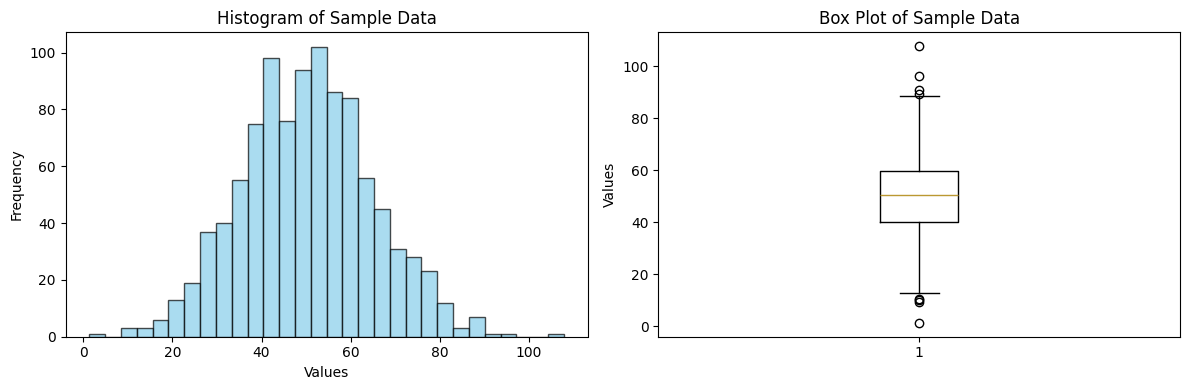

In [5]:
# Example: Descriptive Statistics with Sample Data
np.random.seed(42)
sample_data = np.random.normal(50, 15, 1000)  # Normal distribution with mean=50, std=15

# Create a DataFrame
df = pd.DataFrame({'values': sample_data})

# Calculate descriptive statistics
print("Descriptive Statistics:")
print(f"Mean: {np.mean(sample_data):.2f}")
print(f"Median: {np.median(sample_data):.2f}")
print(f"Standard Deviation: {np.std(sample_data):.2f}")
print(f"Variance: {np.var(sample_data):.2f}")
print(f"Skewness: {stats.skew(sample_data):.2f}")
print(f"Kurtosis: {stats.kurtosis(sample_data):.2f}")

# Visualize the distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
ax1.hist(sample_data, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
ax1.set_title('Histogram of Sample Data')
ax1.set_xlabel('Values')
ax1.set_ylabel('Frequency')

# Box plot
ax2.boxplot(sample_data)
ax2.set_title('Box Plot of Sample Data')
ax2.set_ylabel('Values')

plt.tight_layout()
plt.show()

### 1.2 Inferential Statistics

Inferential statistics allows us to make conclusions about populations based on sample data.

#### Key Concepts:
- **Population**: The entire group we want to study
- **Sample**: A subset of the population used for analysis
- **Parameter**: A numerical characteristic of a population (μ, σ)
- **Statistic**: A numerical characteristic of a sample (x̄, s)

#### Probability Distributions:
- **Normal Distribution**: Bell-shaped, symmetric distribution
- **t-Distribution**: Similar to normal but with heavier tails (used for small samples)
- **Chi-square Distribution**: Used for testing independence and goodness of fit
- **F-Distribution**: Used in ANOVA and regression analysis

#### Central Limit Theorem:
As sample size increases, the sampling distribution of the sample mean approaches a normal distribution, regardless of the population's distribution.

## 2. Machine Learning Fundamentals

Machine Learning (ML) is a subset of artificial intelligence that enables computers to learn and make decisions from data without being explicitly programmed.

### 2.1 What is Machine Learning?

Machine learning algorithms build mathematical models based on training data to make predictions or decisions without being explicitly programmed to perform the task.

#### Key Components:
- **Data**: The fuel of machine learning
- **Algorithm**: The method used to find patterns
- **Model**: The output of an algorithm trained on data
- **Features**: Individual measurable properties of observed phenomena
- **Target/Label**: The outcome we want to predict

### 2.2 The Machine Learning Pipeline

1. **Data Collection**: Gathering relevant data
2. **Data Preprocessing**: Cleaning and preparing data
3. **Feature Selection/Engineering**: Choosing or creating relevant features
4. **Model Selection**: Choosing the appropriate algorithm
5. **Training**: Teaching the model using training data
6. **Validation**: Testing the model's performance
7. **Deployment**: Using the model in production

## 3. Types of Machine Learning

### 3.1 Supervised Learning

In supervised learning, the algorithm learns from labeled training data to make predictions on new, unseen data.

#### Characteristics:
- Uses labeled data (input-output pairs)
- Goal is to learn a mapping function from inputs to outputs
- Performance can be measured against known correct answers

#### Types:
1. **Classification**: Predicting discrete categories or classes
   - Binary Classification: Two classes (e.g., spam/not spam)
   - Multi-class Classification: More than two classes (e.g., animal species)
   
2. **Regression**: Predicting continuous numerical values
   - Linear Regression, Polynomial Regression, etc.

#### Common Algorithms:
- Linear/Logistic Regression
- Decision Trees
- Random Forest
- Support Vector Machines (SVM)
- Neural Networks

### 3.2 Unsupervised Learning

In unsupervised learning, the algorithm finds hidden patterns in data without labeled examples.

#### Characteristics:
- Uses unlabeled data
- Goal is to discover hidden structure in data
- No correct answers to learn from

#### Types:
1. **Clustering**: Grouping similar data points
   - K-Means, Hierarchical Clustering
   
2. **Association**: Finding rules that describe relationships
   - Market Basket Analysis
   
3. **Dimensionality Reduction**: Simplifying data while preserving information
   - Principal Component Analysis (PCA)

### 3.3 Reinforcement Learning

An agent learns to make decisions by receiving rewards or penalties for actions taken in an environment.

#### Characteristics:
- Learns through trial and error
- Uses reward/punishment feedback
- Goal is to maximize cumulative reward

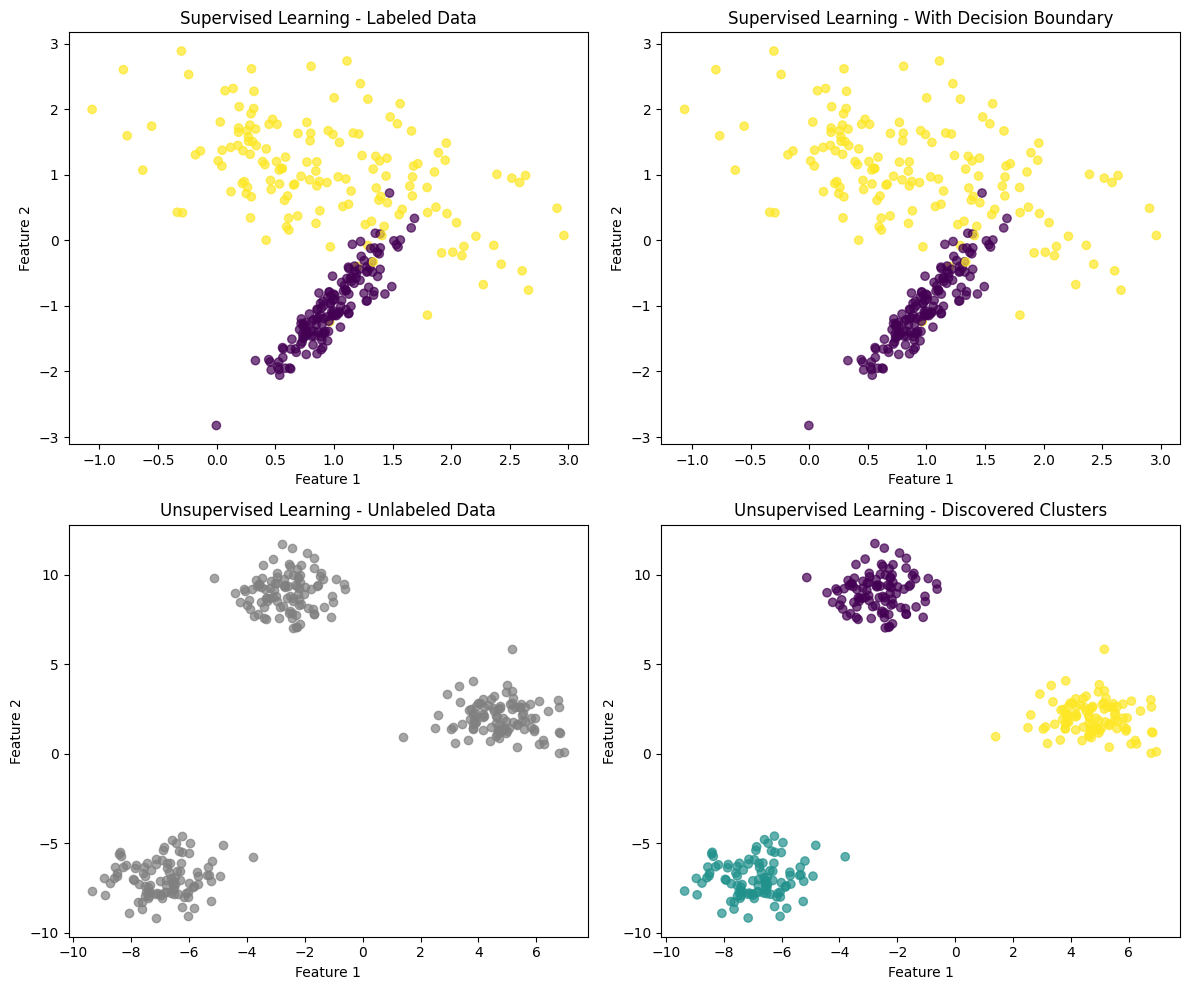

In [6]:
# Example: Supervised vs Unsupervised Learning Visualization
from sklearn.datasets import make_classification, make_blobs
from sklearn.cluster import KMeans

# Create sample data for classification (supervised)
X_supervised, y_supervised = make_classification(n_samples=300, n_features=2, 
                                                n_redundant=0, n_informative=2,
                                                random_state=42, n_clusters_per_class=1)

# Create sample data for clustering (unsupervised)
X_unsupervised, _ = make_blobs(n_samples=300, centers=3, n_features=2,
                              random_state=42, cluster_std=1.0)

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Supervised Learning - Original labeled data
scatter = axes[0, 0].scatter(X_supervised[:, 0], X_supervised[:, 1], 
                            c=y_supervised, cmap='viridis', alpha=0.7)
axes[0, 0].set_title('Supervised Learning - Labeled Data')
axes[0, 0].set_xlabel('Feature 1')
axes[0, 0].set_ylabel('Feature 2')

# Supervised Learning - Decision boundary (simplified)
axes[0, 1].scatter(X_supervised[:, 0], X_supervised[:, 1], 
                  c=y_supervised, cmap='viridis', alpha=0.7)
axes[0, 1].set_title('Supervised Learning - With Decision Boundary')
axes[0, 1].set_xlabel('Feature 1')
axes[0, 1].set_ylabel('Feature 2')

# Unsupervised Learning - Original unlabeled data
axes[1, 0].scatter(X_unsupervised[:, 0], X_unsupervised[:, 1], 
                  c='gray', alpha=0.7)
axes[1, 0].set_title('Unsupervised Learning - Unlabeled Data')
axes[1, 0].set_xlabel('Feature 1')
axes[1, 0].set_ylabel('Feature 2')

# Unsupervised Learning - After clustering
kmeans = KMeans(n_clusters=3, random_state=42)
cluster_labels = kmeans.fit_predict(X_unsupervised)
axes[1, 1].scatter(X_unsupervised[:, 0], X_unsupervised[:, 1], 
                  c=cluster_labels, cmap='viridis', alpha=0.7)
axes[1, 1].set_title('Unsupervised Learning - Discovered Clusters')
axes[1, 1].set_xlabel('Feature 1')
axes[1, 1].set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

## 4. Hypothesis Testing

Hypothesis testing is a statistical method used to make inferences about population parameters based on sample data.

### 4.1 Key Concepts

#### Hypotheses:
- **Null Hypothesis (H₀)**: The default assumption (no effect, no difference)
- **Alternative Hypothesis (H₁ or Hₐ)**: What we want to prove (there is an effect)

#### Types of Errors:
- **Type I Error (α)**: Rejecting H₀ when it's actually true (False Positive)
- **Type II Error (β)**: Failing to reject H₀ when it's actually false (False Negative)
- **Power (1-β)**: Probability of correctly rejecting a false H₀

#### p-value:
The probability of obtaining test results at least as extreme as the observed results, assuming H₀ is true.

#### Significance Level (α):
The threshold for rejecting H₀ (commonly α = 0.05)

### 4.2 Steps in Hypothesis Testing

1. **State the hypotheses** (H₀ and H₁)
2. **Choose significance level** (α)
3. **Select appropriate test statistic**
4. **Calculate the test statistic**
5. **Determine the p-value**
6. **Make a decision** (reject or fail to reject H₀)
7. **State the conclusion**

### 4.3 Common Statistical Tests

- **One-sample t-test**: Compare sample mean to known population mean
- **Two-sample t-test**: Compare means of two groups
- **Paired t-test**: Compare before/after measurements
- **Chi-square test**: Test for independence or goodness of fit
- **ANOVA**: Compare means of multiple groups

Hypothesis Testing Results:
Sample mean: 970.59 hours
Population mean (claimed): 1000 hours
Sample size: 30
Sample standard deviation: 45.00

t-statistic: -3.5793
p-value: 0.0012

Using scipy.stats.ttest_1samp:
t-statistic: -3.5793
p-value: 0.0012

Decision: Reject H₀ (p-value = 0.0012 < α = 0.05)
Conclusion: There is sufficient evidence that the true mean is not 1000 hours


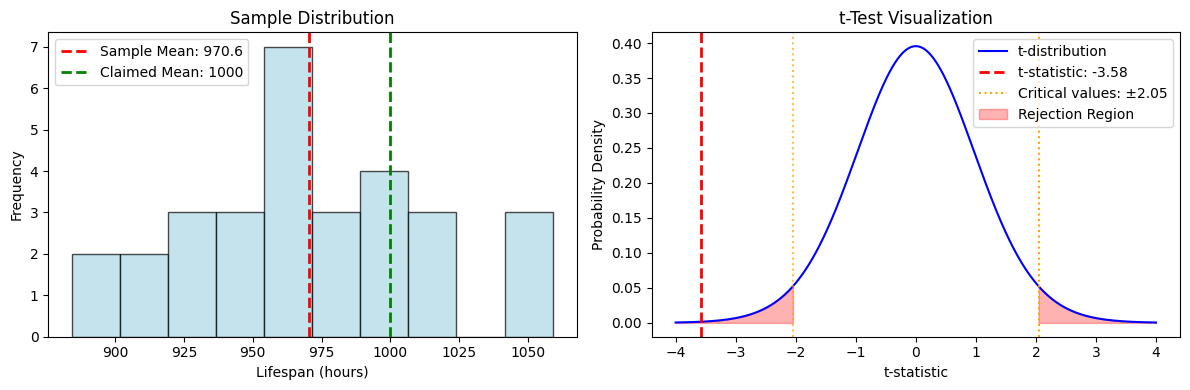

In [7]:
# Example: Hypothesis Testing - One-sample t-test
# Scenario: A manufacturer claims their light bulbs last 1000 hours on average
# We test a sample to see if this claim is true

# Generate sample data (actual mean = 980 hours)
np.random.seed(42)
sample_lifespans = np.random.normal(980, 50, 30)  # n=30, mean=980, std=50

# Hypothesis Test
# H0: μ = 1000 (manufacturer's claim is correct)
# H1: μ ≠ 1000 (manufacturer's claim is incorrect)

population_mean = 1000  # claimed mean
sample_mean = np.mean(sample_lifespans)
sample_std = np.std(sample_lifespans, ddof=1)  # sample standard deviation
n = len(sample_lifespans)

# Calculate t-statistic
t_statistic = (sample_mean - population_mean) / (sample_std / np.sqrt(n))

# Calculate p-value (two-tailed test)
p_value = 2 * (1 - stats.t.cdf(abs(t_statistic), df=n-1))

# Using scipy's built-in t-test
t_stat_scipy, p_value_scipy = stats.ttest_1samp(sample_lifespans, population_mean)

print("Hypothesis Testing Results:")
print("=" * 40)
print(f"Sample mean: {sample_mean:.2f} hours")
print(f"Population mean (claimed): {population_mean} hours")
print(f"Sample size: {n}")
print(f"Sample standard deviation: {sample_std:.2f}")
print()
print(f"t-statistic: {t_statistic:.4f}")
print(f"p-value: {p_value:.4f}")
print()
print(f"Using scipy.stats.ttest_1samp:")
print(f"t-statistic: {t_stat_scipy:.4f}")
print(f"p-value: {p_value_scipy:.4f}")

# Decision
alpha = 0.05
if p_value < alpha:
    print(f"\nDecision: Reject H₀ (p-value = {p_value:.4f} < α = {alpha})")
    print("Conclusion: There is sufficient evidence that the true mean is not 1000 hours")
else:
    print(f"\nDecision: Fail to reject H₀ (p-value = {p_value:.4f} ≥ α = {alpha})")
    print("Conclusion: There is insufficient evidence that the true mean differs from 1000 hours")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Sample distribution
ax1.hist(sample_lifespans, bins=10, alpha=0.7, color='lightblue', edgecolor='black')
ax1.axvline(sample_mean, color='red', linestyle='--', linewidth=2, label=f'Sample Mean: {sample_mean:.1f}')
ax1.axvline(population_mean, color='green', linestyle='--', linewidth=2, label=f'Claimed Mean: {population_mean}')
ax1.set_title('Sample Distribution')
ax1.set_xlabel('Lifespan (hours)')
ax1.set_ylabel('Frequency')
ax1.legend()

# t-distribution with critical regions
x = np.linspace(-4, 4, 1000)
y = stats.t.pdf(x, df=n-1)
ax2.plot(x, y, 'b-', label='t-distribution')
ax2.axvline(t_statistic, color='red', linestyle='--', linewidth=2, label=f't-statistic: {t_statistic:.2f}')

# Critical values for α = 0.05 (two-tailed)
t_critical = stats.t.ppf(1 - alpha/2, df=n-1)
ax2.axvline(t_critical, color='orange', linestyle=':', label=f'Critical values: ±{t_critical:.2f}')
ax2.axvline(-t_critical, color='orange', linestyle=':', alpha=0.7)

# Shade critical regions
x_crit_right = x[x >= t_critical]
y_crit_right = stats.t.pdf(x_crit_right, df=n-1)
x_crit_left = x[x <= -t_critical]
y_crit_left = stats.t.pdf(x_crit_left, df=n-1)

ax2.fill_between(x_crit_right, y_crit_right, alpha=0.3, color='red', label='Rejection Region')
ax2.fill_between(x_crit_left, y_crit_left, alpha=0.3, color='red')

ax2.set_title('t-Test Visualization')
ax2.set_xlabel('t-statistic')
ax2.set_ylabel('Probability Density')
ax2.legend()

plt.tight_layout()
plt.show()

## 5. Regression Analysis

Regression analysis is a statistical method used to model and analyze the relationship between a dependent variable (target) and one or more independent variables (predictors).

### 5.1 Simple Linear Regression

Models the relationship between two variables using a straight line.

**Equation**: y = β₀ + β₁x + ε

Where:
- y = dependent variable (response)
- x = independent variable (predictor)
- β₀ = y-intercept
- β₁ = slope (regression coefficient)
- ε = error term

#### Assumptions:
1. **Linearity**: The relationship is linear
2. **Independence**: Observations are independent
3. **Homoscedasticity**: Constant variance of errors
4. **Normality**: Errors are normally distributed

### 5.2 Multiple Linear Regression

Extends simple regression to multiple predictors.

**Equation**: y = β₀ + β₁x₁ + β₂x₂ + ... + βₚxₚ + ε

#### Key Metrics:
- **R²**: Coefficient of determination (proportion of variance explained)
- **Adjusted R²**: R² adjusted for the number of predictors
- **F-statistic**: Overall model significance
- **p-values**: Individual coefficient significance

### 5.3 Model Evaluation

- **Mean Squared Error (MSE)**: Average of squared residuals
- **Root Mean Squared Error (RMSE)**: Square root of MSE
- **Mean Absolute Error (MAE)**: Average of absolute residuals
- **Residual Analysis**: Checking model assumptions

Linear Regression Results:
Intercept (β₀): $23,070.51
Slope (β₁): $48.16 per sq ft

Model Performance:
R² Score: 0.9403
RMSE: $8,981.01
MAE: $7,010.43

Interpretation:
- For every additional sq ft, the price increases by $48.16
- The model explains 94.0% of the variance in house prices


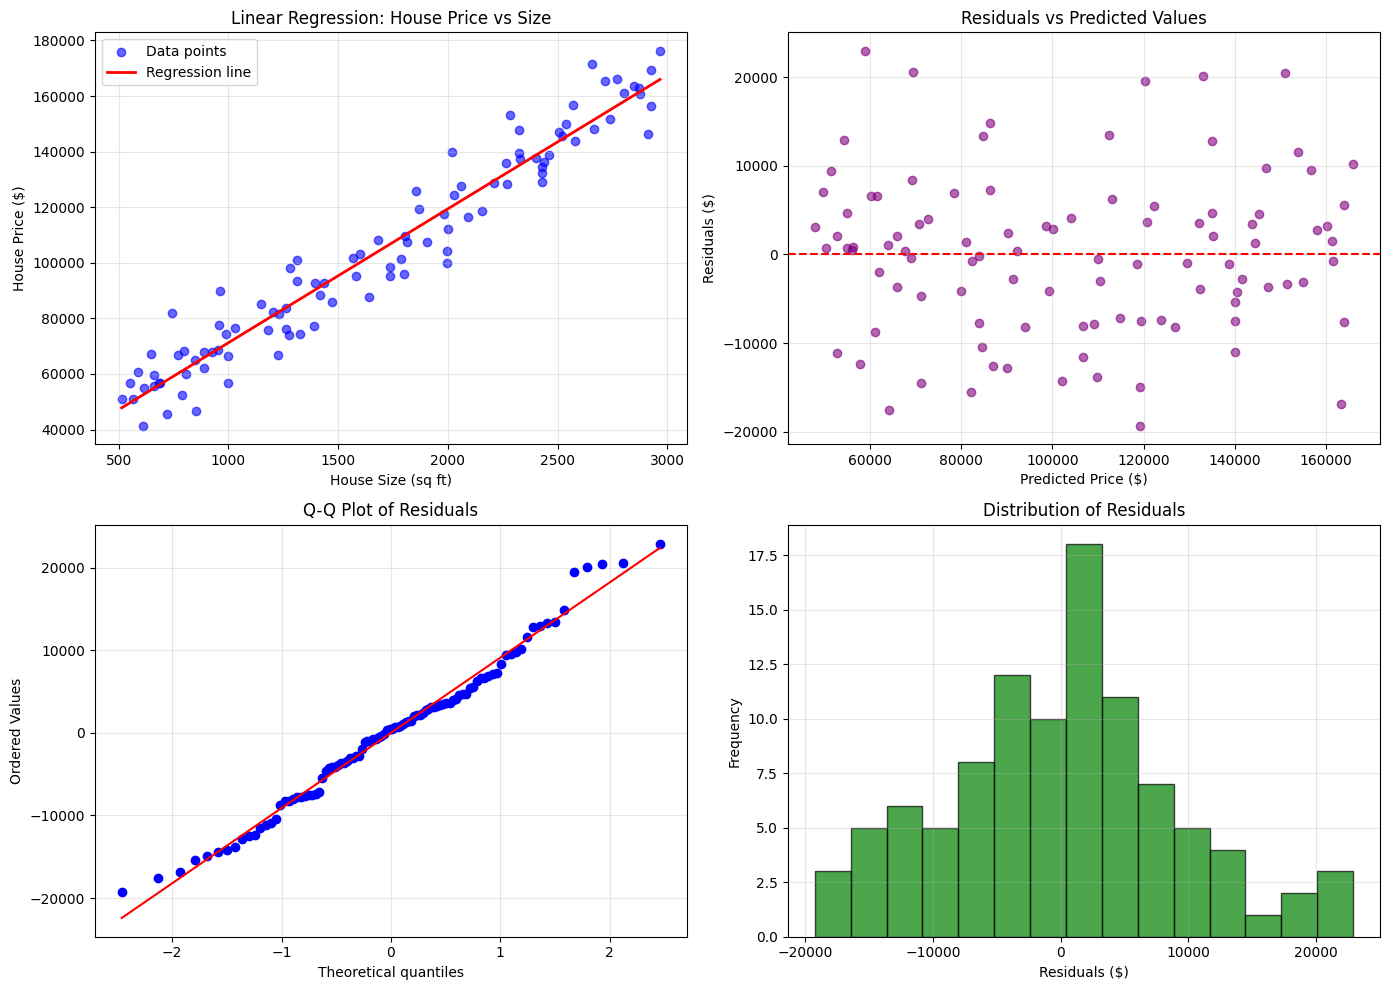


Sample Prediction:
A house of 1500 sq ft is predicted to cost $95,311.87


In [8]:
# Example: Linear Regression Analysis
# Scenario: Predicting house prices based on house size

# Generate sample data
np.random.seed(42)
house_size = np.random.uniform(500, 3000, 100)  # House size in sq ft
# Price = 50 * size + 20000 + noise
house_price = 50 * house_size + 20000 + np.random.normal(0, 10000, 100)

# Create DataFrame
df_houses = pd.DataFrame({
    'size': house_size,
    'price': house_price
})

# Fit linear regression model
X = df_houses[['size']]
y = df_houses['price']

model = LinearRegression()
model.fit(X, y)

# Make predictions
y_pred = model.predict(X)

# Calculate metrics
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("Linear Regression Results:")
print("=" * 40)
print(f"Intercept (β₀): ${model.intercept_:,.2f}")
print(f"Slope (β₁): ${model.coef_[0]:.2f} per sq ft")
print()
print("Model Performance:")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"MAE: ${mae:,.2f}")
print()
print(f"Interpretation:")
print(f"- For every additional sq ft, the price increases by ${model.coef_[0]:.2f}")
print(f"- The model explains {r2*100:.1f}% of the variance in house prices")

# Create visualizations
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# Scatter plot with regression line
ax1.scatter(house_size, house_price, alpha=0.6, color='blue', label='Data points')
x_line = np.linspace(house_size.min(), house_size.max(), 100)
y_line = model.predict(x_line.reshape(-1, 1))
ax1.plot(x_line, y_line, 'r-', linewidth=2, label='Regression line')
ax1.set_xlabel('House Size (sq ft)')
ax1.set_ylabel('House Price ($)')
ax1.set_title('Linear Regression: House Price vs Size')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Residuals plot
residuals = y - y_pred
ax2.scatter(y_pred, residuals, alpha=0.6, color='purple')
ax2.axhline(y=0, color='red', linestyle='--')
ax2.set_xlabel('Predicted Price ($)')
ax2.set_ylabel('Residuals ($)')
ax2.set_title('Residuals vs Predicted Values')
ax2.grid(True, alpha=0.3)

# Q-Q plot for residual normality
from scipy.stats import probplot
probplot(residuals, dist="norm", plot=ax3)
ax3.set_title('Q-Q Plot of Residuals')
ax3.grid(True, alpha=0.3)

# Histogram of residuals
ax4.hist(residuals, bins=15, alpha=0.7, color='green', edgecolor='black')
ax4.set_xlabel('Residuals ($)')
ax4.set_ylabel('Frequency')
ax4.set_title('Distribution of Residuals')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print("\nSample Prediction:")
print("=" * 20)
sample_size = 1500  # sq ft
predicted_price = model.predict([[sample_size]])[0]
print(f"A house of {sample_size} sq ft is predicted to cost ${predicted_price:,.2f}")

## 6. Analysis of Variance (ANOVA)

ANOVA is a statistical technique used to compare means among three or more groups to determine if there are statistically significant differences.

### 6.1 Types of ANOVA

#### One-Way ANOVA
- Compares means of **one factor** with multiple levels
- **Null Hypothesis**: All group means are equal (μ₁ = μ₂ = μ₃ = ...)
- **Alternative Hypothesis**: At least one group mean is different

#### Two-Way ANOVA
- Examines the effect of **two factors** simultaneously
- Can detect **main effects** and **interaction effects**

#### Repeated Measures ANOVA
- Used when the same subjects are measured multiple times

### 6.2 ANOVA Assumptions

1. **Independence**: Observations are independent
2. **Normality**: Data in each group is normally distributed
3. **Homogeneity of Variance**: Equal variances across groups (homoscedasticity)

### 6.3 ANOVA Table Components

- **Sum of Squares (SS)**:
  - SST (Total): Total variation in data
  - SSB (Between): Variation between groups
  - SSW (Within): Variation within groups
  
- **Degrees of Freedom (df)**:
  - df_between = k - 1 (k = number of groups)
  - df_within = N - k (N = total sample size)
  
- **Mean Squares (MS)**: SS / df
- **F-statistic**: MSB / MSW
- **p-value**: Probability of observing F-statistic under H₀

### 6.4 Post-Hoc Tests

When ANOVA is significant, post-hoc tests identify which specific groups differ:
- **Tukey's HSD**: Controls family-wise error rate
- **Bonferroni**: Conservative adjustment for multiple comparisons
- **Scheffé**: Most conservative, used for complex comparisons

One-Way ANOVA Results:
Group Statistics:
Method A (Traditional): Mean = 73.12, SD = 9.00, n = 30
Method B (Interactive): Mean = 78.55, SD = 11.17, n = 30
Method C (Online):      Mean = 85.10, SD = 7.94, n = 30
Overall Mean: 78.92

ANOVA Table:
----------------------------------------------------------------------
Source          SS         df    MS         F        p-value   
----------------------------------------------------------------------
Between Groups  2160.82    2     1080.41    12.0572  0.000024  
Within Groups   7795.78    87    89.61     
Total           9956.60    89   
----------------------------------------------------------------------

Decision: Reject H₀ (p-value = 0.000024 < α = 0.05)
Conclusion: There is a significant difference between teaching methods


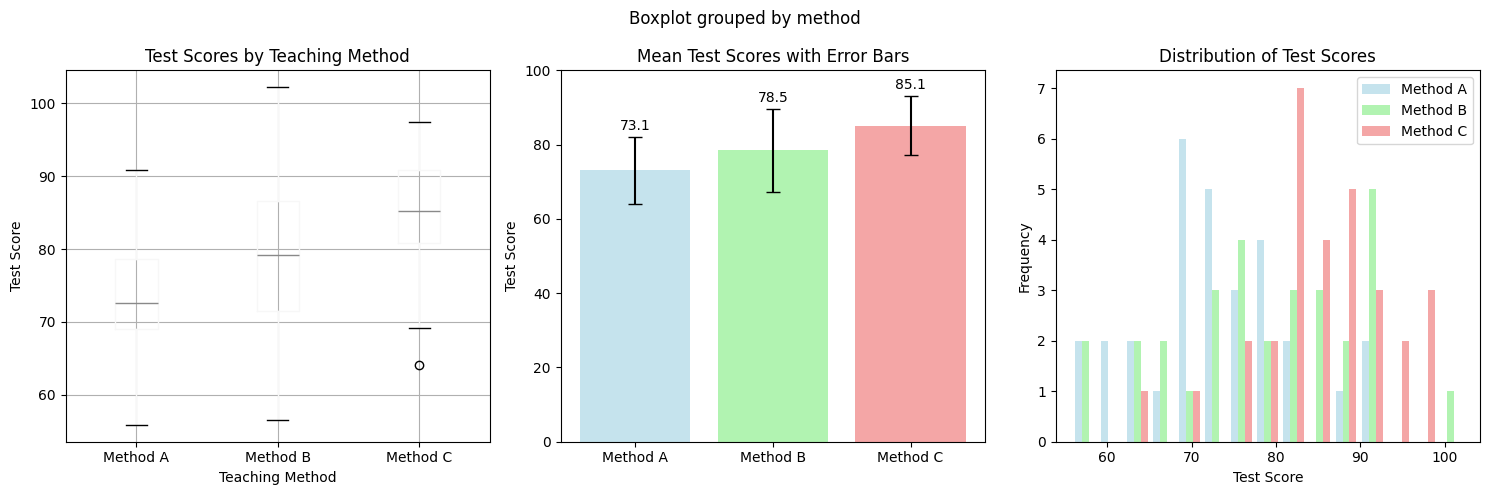


Effect Size (η²): 0.2170
Effect Size Interpretation: large


In [9]:
# Example: One-Way ANOVA
# Scenario: Testing if three different teaching methods result in different test scores

# Generate sample data for three teaching methods
np.random.seed(42)
method_A = np.random.normal(75, 10, 30)  # Traditional method
method_B = np.random.normal(80, 12, 30)  # Interactive method  
method_C = np.random.normal(85, 8, 30)   # Online method

# Combine data
all_scores = np.concatenate([method_A, method_B, method_C])
groups = ['Method A'] * 30 + ['Method B'] * 30 + ['Method C'] * 30

# Create DataFrame
df_anova = pd.DataFrame({
    'score': all_scores,
    'method': groups
})

# Perform One-Way ANOVA
from scipy.stats import f_oneway
f_stat, p_value_anova = f_oneway(method_A, method_B, method_C)

# Calculate ANOVA components manually for educational purposes
n1, n2, n3 = len(method_A), len(method_B), len(method_C)
N = n1 + n2 + n3
k = 3  # number of groups

# Group means and overall mean
mean_A, mean_B, mean_C = np.mean(method_A), np.mean(method_B), np.mean(method_C)
overall_mean = np.mean(all_scores)

# Sum of Squares
SST = np.sum((all_scores - overall_mean)**2)
SSB = n1*(mean_A - overall_mean)**2 + n2*(mean_B - overall_mean)**2 + n3*(mean_C - overall_mean)**2
SSW = np.sum((method_A - mean_A)**2) + np.sum((method_B - mean_B)**2) + np.sum((method_C - mean_C)**2)

# Degrees of freedom
df_between = k - 1
df_within = N - k

# Mean Squares
MSB = SSB / df_between
MSW = SSW / df_within

# F-statistic
F_calculated = MSB / MSW

print("One-Way ANOVA Results:")
print("=" * 50)
print("Group Statistics:")
print(f"Method A (Traditional): Mean = {mean_A:.2f}, SD = {np.std(method_A, ddof=1):.2f}, n = {n1}")
print(f"Method B (Interactive): Mean = {mean_B:.2f}, SD = {np.std(method_B, ddof=1):.2f}, n = {n2}")
print(f"Method C (Online):      Mean = {mean_C:.2f}, SD = {np.std(method_C, ddof=1):.2f}, n = {n3}")
print(f"Overall Mean: {overall_mean:.2f}")
print()

print("ANOVA Table:")
print("-" * 70)
print(f"{'Source':<15} {'SS':<10} {'df':<5} {'MS':<10} {'F':<8} {'p-value':<10}")
print("-" * 70)
print(f"{'Between Groups':<15} {SSB:<10.2f} {df_between:<5} {MSB:<10.2f} {F_calculated:<8.4f} {p_value_anova:<10.6f}")
print(f"{'Within Groups':<15} {SSW:<10.2f} {df_within:<5} {MSW:<10.2f}")
print(f"{'Total':<15} {SST:<10.2f} {N-1:<5}")
print("-" * 70)

# Decision
alpha = 0.05
if p_value_anova < alpha:
    print(f"\nDecision: Reject H₀ (p-value = {p_value_anova:.6f} < α = {alpha})")
    print("Conclusion: There is a significant difference between teaching methods")
else:
    print(f"\nDecision: Fail to reject H₀ (p-value = {p_value_anova:.6f} ≥ α = {alpha})")
    print("Conclusion: No significant difference between teaching methods")

# Visualizations
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Box plot
df_anova.boxplot(column='score', by='method', ax=ax1)
ax1.set_title('Test Scores by Teaching Method')
ax1.set_xlabel('Teaching Method')
ax1.set_ylabel('Test Score')

# Bar plot with error bars
methods = ['Method A', 'Method B', 'Method C']
means = [mean_A, mean_B, mean_C]
stds = [np.std(method_A, ddof=1), np.std(method_B, ddof=1), np.std(method_C, ddof=1)]

ax2.bar(methods, means, yerr=stds, capsize=5, alpha=0.7, 
        color=['lightblue', 'lightgreen', 'lightcoral'])
ax2.set_title('Mean Test Scores with Error Bars')
ax2.set_ylabel('Test Score')
ax2.set_ylim(0, 100)

# Add value labels on bars
for i, (mean, std) in enumerate(zip(means, stds)):
    ax2.text(i, mean + std + 1, f'{mean:.1f}', ha='center', va='bottom')

# Histogram of all groups
ax3.hist([method_A, method_B, method_C], bins=15, alpha=0.7, 
         label=['Method A', 'Method B', 'Method C'], 
         color=['lightblue', 'lightgreen', 'lightcoral'])
ax3.set_title('Distribution of Test Scores')
ax3.set_xlabel('Test Score')
ax3.set_ylabel('Frequency')
ax3.legend()

plt.tight_layout()
plt.show()

# Effect size (Eta-squared)
eta_squared = SSB / SST
print(f"\nEffect Size (η²): {eta_squared:.4f}")
if eta_squared < 0.01:
    effect_size = "small"
elif eta_squared < 0.06:
    effect_size = "medium"
else:
    effect_size = "large"
print(f"Effect Size Interpretation: {effect_size}")

## 7. Classification

Classification is a supervised learning task where the goal is to predict discrete categorical labels or classes.

### 7.1 Types of Classification

#### Binary Classification
- **Two classes** (e.g., spam/not spam, pass/fail)
- Common algorithms: Logistic Regression, SVM, Decision Trees

#### Multi-class Classification  
- **More than two classes** (e.g., image recognition, species classification)
- Strategies: One-vs-Rest, One-vs-One

#### Multi-label Classification
- **Multiple labels** can be assigned to each instance
- Example: Text categorization (politics + economics)

### 7.2 Classification Algorithms

#### Decision Trees
- Easy to interpret and visualize
- Handle both numerical and categorical features
- Prone to overfitting

#### Random Forest
- Ensemble of decision trees
- Reduces overfitting
- Provides feature importance

#### Support Vector Machines (SVM)
- Effective for high-dimensional data
- Works well with limited data
- Can use different kernels

#### k-Nearest Neighbors (k-NN)
- Instance-based learning
- No assumptions about data distribution
- Computationally expensive for large datasets

### 7.3 Performance Metrics

#### Confusion Matrix
```
                Predicted
              |  0  |  1  |
    Actual  0 | TN  | FP  |
            1 | FN  | TP  |
```

#### Key Metrics:
- **Accuracy**: (TP + TN) / (TP + TN + FP + FN)
- **Precision**: TP / (TP + FP) - "Of predicted positives, how many are correct?"
- **Recall (Sensitivity)**: TP / (TP + FN) - "Of actual positives, how many were found?"
- **Specificity**: TN / (TN + FP) - "Of actual negatives, how many were correctly identified?"
- **F1-Score**: 2 × (Precision × Recall) / (Precision + Recall)

#### ROC Curve and AUC
- **ROC Curve**: Plot of True Positive Rate vs False Positive Rate
- **AUC**: Area Under the ROC Curve (0.5 = random, 1.0 = perfect)

Binary Classification Results:
Dataset Size: 500 samples
Training Set: 400 samples
Test Set: 100 samples
Class Distribution: [148 352] (No Purchase: 148, Purchase: 352)

Test Accuracy: 0.6900

Confusion Matrix:
[[ 4 22]
 [ 9 65]]

Classification Report:
              precision    recall  f1-score   support

 No Purchase       0.31      0.15      0.21        26
    Purchase       0.75      0.88      0.81        74

    accuracy                           0.69       100
   macro avg       0.53      0.52      0.51       100
weighted avg       0.63      0.69      0.65       100

Detailed Metrics:
True Positives: 65
True Negatives: 4
False Positives: 22
False Negatives: 9
Precision: 0.7471
Recall (Sensitivity): 0.8784
Specificity: 0.1538
F1-Score: 0.8075


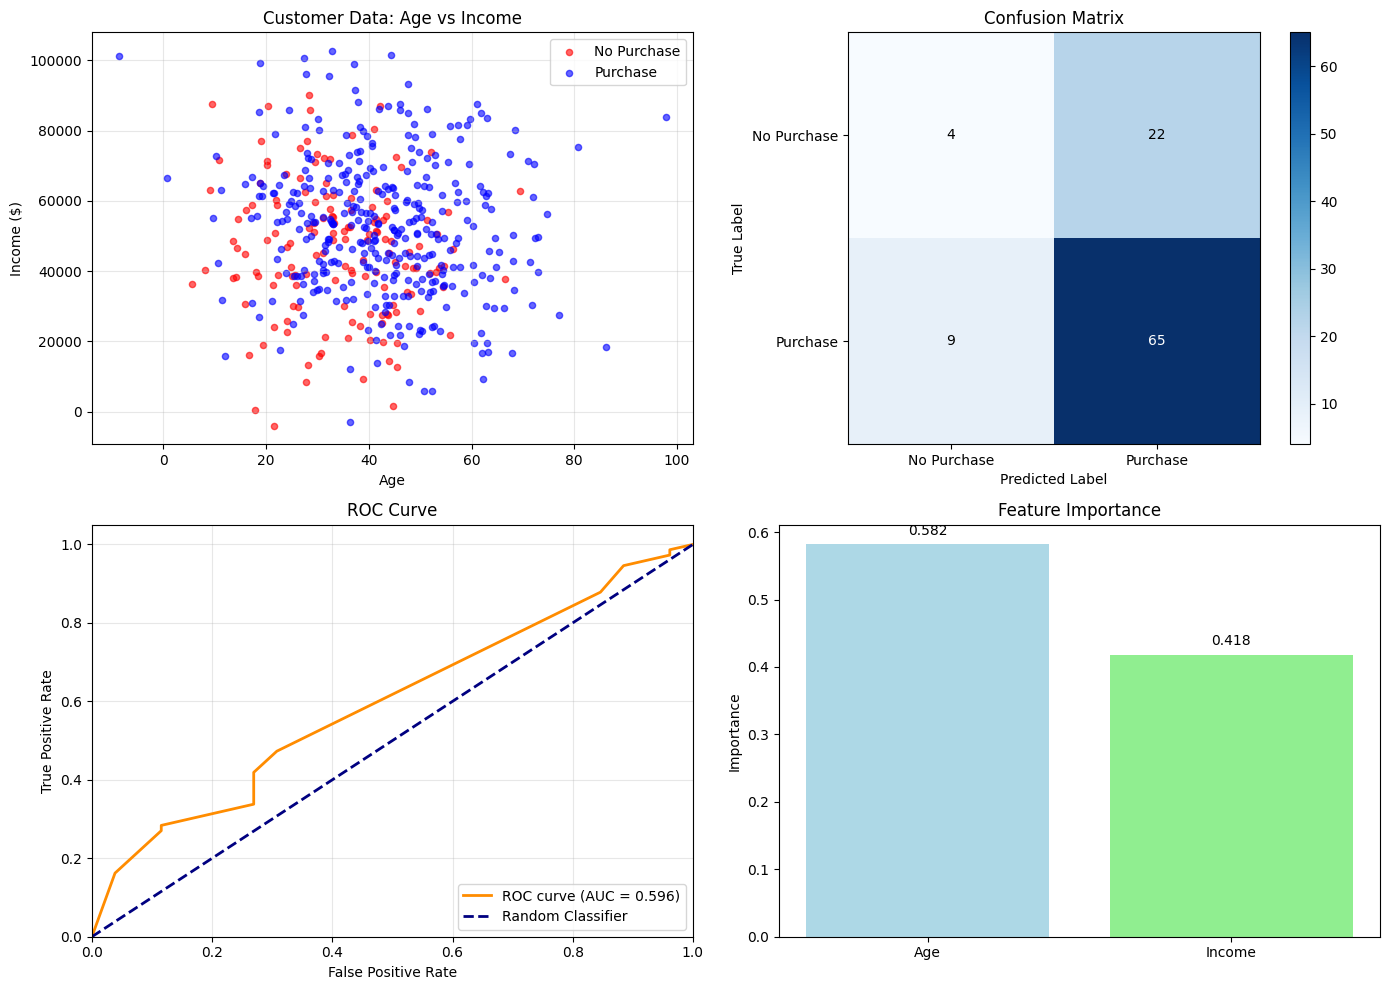


ROC AUC Score: 0.5956
Feature Importances:
  Age: 0.5817
  Income: 0.4183


In [10]:
# Example: Binary Classification with Decision Tree
# Scenario: Predicting whether a customer will purchase a product based on age and income

# Generate sample data
np.random.seed(42)
n_samples = 500

# Create features: age and income
age = np.random.normal(40, 15, n_samples)
income = np.random.normal(50000, 20000, n_samples)

# Create target: purchase decision (influenced by age and income)
# Higher probability of purchase for middle-aged customers with higher income
purchase_prob = 1 / (1 + np.exp(-(0.05 * (age - 30) + 0.00002 * (income - 30000))))
purchase = np.random.binomial(1, purchase_prob)

# Create DataFrame
df_classification = pd.DataFrame({
    'age': age,
    'income': income,
    'purchase': purchase
})

# Prepare data for modeling
X = df_classification[['age', 'income']]
y = df_classification['purchase']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

dt_classifier = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_classifier.fit(X_train, y_train)

# Make predictions
y_pred = dt_classifier.predict(X_test)
y_pred_proba = dt_classifier.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("Binary Classification Results:")
print("=" * 50)
print(f"Dataset Size: {len(df_classification)} samples")
print(f"Training Set: {len(X_train)} samples")
print(f"Test Set: {len(X_test)} samples")
print(f"Class Distribution: {np.bincount(y)} (No Purchase: {np.bincount(y)[0]}, Purchase: {np.bincount(y)[1]})")
print()

print(f"Test Accuracy: {accuracy:.4f}")
print()

print("Confusion Matrix:")
print(conf_matrix)
print()

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Purchase', 'Purchase']))

# Calculate individual metrics
tn, fp, fn, tp = conf_matrix.ravel()
precision = tp / (tp + fp)
recall = tp / (tp + fn)
specificity = tn / (tn + fp)
f1 = 2 * (precision * recall) / (precision + recall)

print(f"Detailed Metrics:")
print(f"True Positives: {tp}")
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-Score: {f1:.4f}")

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Visualizations
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# Scatter plot of data with true labels
colors = ['red', 'blue']
labels = ['No Purchase', 'Purchase']
for i in range(2):
    mask = df_classification['purchase'] == i
    ax1.scatter(df_classification[mask]['age'], df_classification[mask]['income'], 
               c=colors[i], alpha=0.6, label=labels[i], s=20)

ax1.set_xlabel('Age')
ax1.set_ylabel('Income ($)')
ax1.set_title('Customer Data: Age vs Income')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Confusion Matrix Heatmap
im = ax2.imshow(conf_matrix, interpolation='nearest', cmap='Blues')
ax2.figure.colorbar(im, ax=ax2)
ax2.set(xticks=np.arange(conf_matrix.shape[1]),
        yticks=np.arange(conf_matrix.shape[0]),
        xticklabels=['No Purchase', 'Purchase'],
        yticklabels=['No Purchase', 'Purchase'],
        title='Confusion Matrix',
        ylabel='True Label',
        xlabel='Predicted Label')

# Add text annotations
thresh = conf_matrix.max() / 2.
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        ax2.text(j, i, format(conf_matrix[i, j], 'd'),
                ha="center", va="center",
                color="white" if conf_matrix[i, j] > thresh else "black")

# ROC Curve
ax3.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
ax3.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax3.set_xlim([0.0, 1.0])
ax3.set_ylim([0.0, 1.05])
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.set_title('ROC Curve')
ax3.legend(loc="lower right")
ax3.grid(True, alpha=0.3)

# Feature Importance
feature_names = ['Age', 'Income']
importances = dt_classifier.feature_importances_
ax4.bar(feature_names, importances, color=['lightblue', 'lightgreen'])
ax4.set_title('Feature Importance')
ax4.set_ylabel('Importance')
for i, importance in enumerate(importances):
    ax4.text(i, importance + 0.01, f'{importance:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print(f"\nROC AUC Score: {roc_auc:.4f}")
print(f"Feature Importances:")
for name, importance in zip(feature_names, importances):
    print(f"  {name}: {importance:.4f}")

## 8. Logistic Regression

Logistic regression is a statistical method used for binary and multi-class classification problems. Unlike linear regression, it predicts probabilities using the logistic function.

### 8.1 The Logistic Function (Sigmoid)

**Equation**: p = 1 / (1 + e^(-z))

Where z = β₀ + β₁x₁ + β₂x₂ + ... + βₚxₚ

#### Key Properties:
- Output ranges from 0 to 1 (probability)
- S-shaped curve
- Monotonic (always increasing)
- Symmetric around p = 0.5

### 8.2 Odds and Log-Odds

#### Odds
**Odds = p / (1 - p)**
- Ratio of probability of success to probability of failure
- Range: 0 to ∞

#### Log-Odds (Logit)
**Logit(p) = ln(p / (1 - p)) = β₀ + β₁x₁ + β₂x₂ + ... + βₚxₚ**
- Natural logarithm of odds
- Range: -∞ to ∞
- Linear relationship with predictors

### 8.3 Interpretation of Coefficients

- **β₀**: Log-odds when all predictors = 0
- **βᵢ**: Change in log-odds for one unit increase in xᵢ
- **e^βᵢ**: Odds ratio - multiplicative effect on odds

#### Example:
If β₁ = 0.693, then e^0.693 ≈ 2
- One unit increase in x₁ doubles the odds

### 8.4 Model Fitting and Assessment

#### Maximum Likelihood Estimation
- Uses iterative algorithms (Newton-Raphson, IRLS)
- Maximizes likelihood of observed data

#### Model Assessment:
- **Deviance**: Measure of model fit (-2 × log-likelihood)
- **AIC/BIC**: Information criteria for model comparison
- **Pseudo R²**: Various measures (McFadden's, Nagelkerke's)
- **Hosmer-Lemeshow Test**: Goodness-of-fit test

### 8.5 Assumptions

1. **Linearity**: Linear relationship between logit and predictors
2. **Independence**: Observations are independent
3. **No Perfect Multicollinearity**: Predictors shouldn't be perfectly correlated
4. **Large Sample Size**: Generally need large samples for stable results

Class distribution before adjustment:
Not Admitted (0): 153
Admitted (1): 247

Final class distribution:
Not Admitted (0): 153
Admitted (1): 247
Admission rate: 61.8%

Training set class distribution:
Not Admitted (0): 122
Admitted (1): 198

Logistic Regression Analysis:
Model Equation:
Logit(p) = -9.5678 + 0.009357 × GRE + 2.2783 × GPA

Coefficient Interpretation:
Intercept (β₀): -9.5678
GRE Coefficient (β₁): 0.009357
  - Odds Ratio: e^0.009357 = 1.0094
  - Interpretation: 1 point increase in GRE multiplies odds by 1.0094
GPA Coefficient (β₂): 2.2783
  - Odds Ratio: e^2.2783 = 9.7601
  - Interpretation: 1 point increase in GPA multiplies odds by 9.8

Model Performance:
Training Accuracy: 0.7469
Test Accuracy: 0.7375

Confusion Matrix:
[[19 12]
 [ 9 40]]

ROC AUC: 0.8157

Sample Predictions:
------------------------------
Student 1: GRE=280, GPA=2.5
  Log-odds: -1.2522
  Probability: 0.2223
  Prediction: Not Admitted

Student 2: GRE=320, GPA=3.2
  Log-odds: 0.7169
  Probability: 0.6719

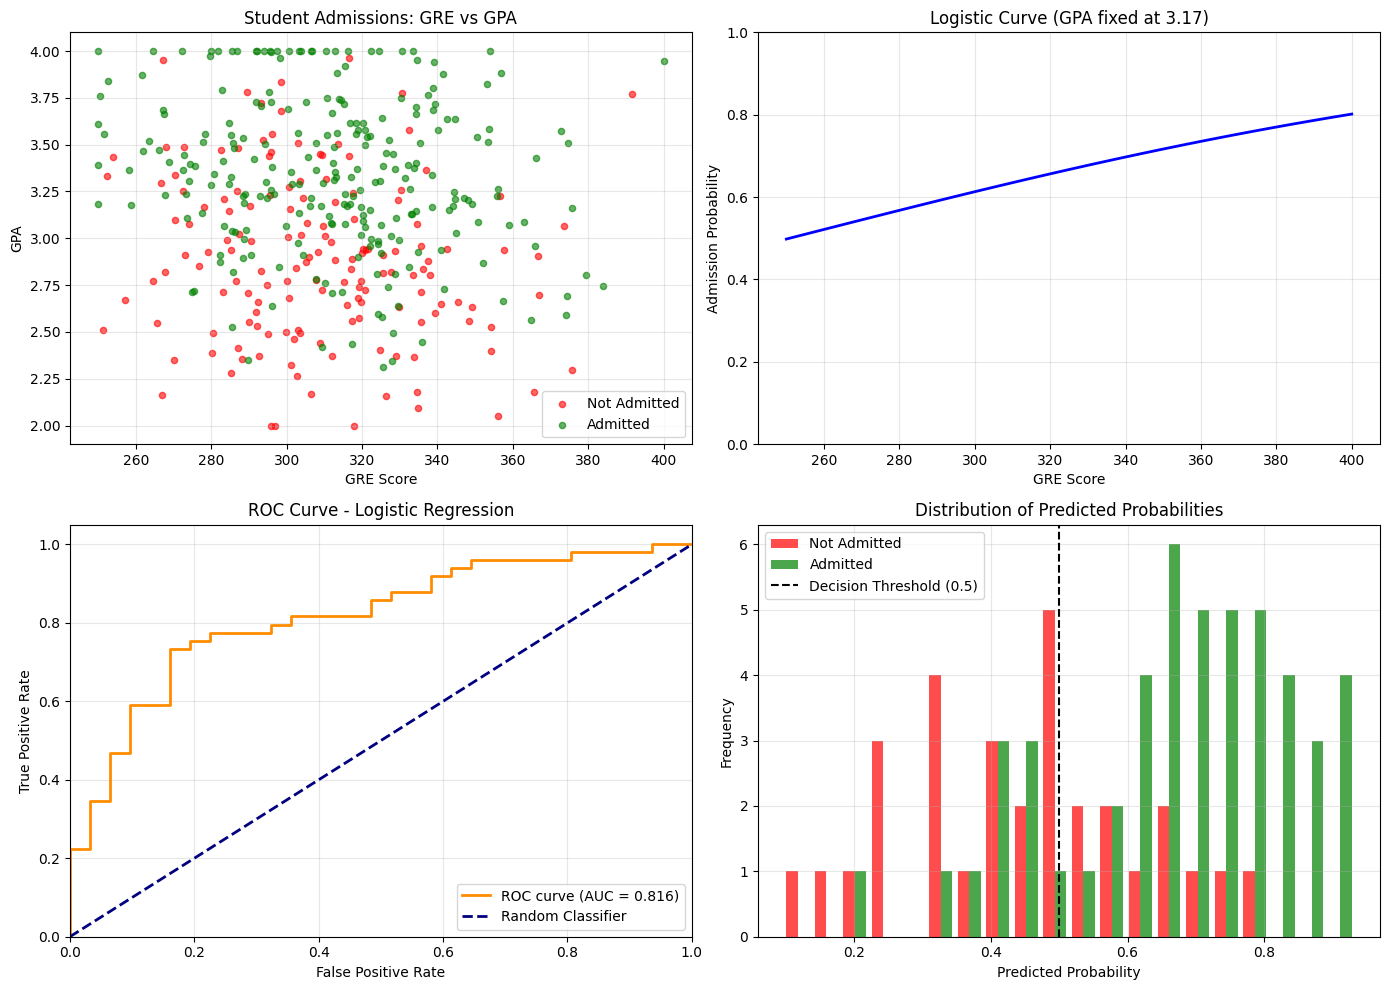

McFadden's Pseudo R²: 0.1869

Odds Ratio Interpretation:
For a 10-point increase in GRE score:
  Odds multiply by: 1.10
For a 0.1-point increase in GPA:
  Odds multiply by: 1.26


In [14]:
# Example: Logistic Regression Analysis
# Scenario: Predicting student admission based on GRE score and GPA

# Import additional required modules
from sklearn.metrics import roc_curve, auc

# Generate sample data
np.random.seed(42)
n_students = 400

# Generate GRE scores and GPA with wider ranges
gre_score = np.random.normal(310, 30, n_students)  # Wider range for GRE
gpa = np.random.normal(3.2, 0.5, n_students)      # Wider range for GPA

# Ensure realistic bounds
gre_score = np.clip(gre_score, 250, 400)  # GRE typically 260-340
gpa = np.clip(gpa, 2.0, 4.0)              # GPA typically 2.0-4.0

# Create admission probability based on GRE and GPA
# Adjusted coefficients to create a more balanced dataset
z = -15 + 0.02 * gre_score + 3 * gpa + np.random.normal(0, 1, n_students)
admission_prob = 1 / (1 + np.exp(-z))

# Generate binary admission decisions
admitted = np.random.binomial(1, admission_prob)

# Check class distribution and adjust if necessary
print(f"Class distribution before adjustment:")
print(f"Not Admitted (0): {np.sum(admitted == 0)}")
print(f"Admitted (1): {np.sum(admitted == 1)}")

# If we have very imbalanced classes, let's manually create a more balanced dataset
if np.sum(admitted == 0) < 50 or np.sum(admitted == 1) < 50:
    print("Adjusting for better class balance...")
    
    # Create a more balanced dataset manually
    np.random.seed(42)
    
    # Generate two groups: lower performers (more likely rejected) and higher performers (more likely accepted)
    n_low = n_students // 2
    n_high = n_students - n_low
    
    # Lower performing students
    gre_low = np.random.normal(290, 20, n_low)
    gpa_low = np.random.normal(2.8, 0.3, n_low)
    
    # Higher performing students  
    gre_high = np.random.normal(340, 20, n_high)
    gpa_high = np.random.normal(3.6, 0.3, n_high)
    
    # Combine
    gre_score = np.concatenate([gre_low, gre_high])
    gpa = np.concatenate([gpa_low, gpa_high])
    
    # Ensure bounds
    gre_score = np.clip(gre_score, 250, 400)
    gpa = np.clip(gpa, 2.0, 4.0)
    
    # Create more realistic admission probabilities
    z = -12 + 0.015 * gre_score + 2.5 * gpa + np.random.normal(0, 0.8, n_students)
    admission_prob = 1 / (1 + np.exp(-z))
    admitted = np.random.binomial(1, admission_prob)

print(f"\nFinal class distribution:")
print(f"Not Admitted (0): {np.sum(admitted == 0)}")
print(f"Admitted (1): {np.sum(admitted == 1)}")
print(f"Admission rate: {np.mean(admitted):.1%}")

# Create DataFrame
df_logistic = pd.DataFrame({
    'gre_score': gre_score,
    'gpa': gpa,
    'admitted': admitted
})

# Prepare data
X_log = df_logistic[['gre_score', 'gpa']]
y_log = df_logistic['admitted']

# Split data
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_log, y_log, test_size=0.2, random_state=42, stratify=y_log
)

# Check that both classes are present in training set
print(f"\nTraining set class distribution:")
print(f"Not Admitted (0): {np.sum(y_train_log == 0)}")
print(f"Admitted (1): {np.sum(y_train_log == 1)}")

# Fit logistic regression
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_log, y_train_log)

# Predictions
y_pred_log = log_reg.predict(X_test_log)
y_pred_proba_log = log_reg.predict_proba(X_test_log)[:, 1]

# Model coefficients and statistics
intercept = log_reg.intercept_[0]
coef_gre = log_reg.coef_[0][0]
coef_gpa = log_reg.coef_[0][1]

print("\n" + "="*50)
print("Logistic Regression Analysis:")
print("=" * 50)
print("Model Equation:")
print(f"Logit(p) = {intercept:.4f} + {coef_gre:.6f} × GRE + {coef_gpa:.4f} × GPA")
print()

print("Coefficient Interpretation:")
print(f"Intercept (β₀): {intercept:.4f}")
print(f"GRE Coefficient (β₁): {coef_gre:.6f}")
print(f"  - Odds Ratio: e^{coef_gre:.6f} = {np.exp(coef_gre):.4f}")
print(f"  - Interpretation: 1 point increase in GRE multiplies odds by {np.exp(coef_gre):.4f}")
print(f"GPA Coefficient (β₂): {coef_gpa:.4f}")
print(f"  - Odds Ratio: e^{coef_gpa:.4f} = {np.exp(coef_gpa):.4f}")
print(f"  - Interpretation: 1 point increase in GPA multiplies odds by {np.exp(coef_gpa):.1f}")
print()

# Model performance
accuracy_log = accuracy_score(y_test_log, y_pred_log)
conf_matrix_log = confusion_matrix(y_test_log, y_pred_log)

print(f"Model Performance:")
print(f"Training Accuracy: {log_reg.score(X_train_log, y_train_log):.4f}")
print(f"Test Accuracy: {accuracy_log:.4f}")
print()

print("Confusion Matrix:")
print(conf_matrix_log)
print()

# ROC Analysis
fpr_log, tpr_log, _ = roc_curve(y_test_log, y_pred_proba_log)
auc_log = auc(fpr_log, tpr_log)
print(f"ROC AUC: {auc_log:.4f}")

# Example predictions
print("\nSample Predictions:")
print("-" * 30)
sample_students = [[280, 2.5], [320, 3.2], [350, 3.8]]
for i, (gre, gpa_val) in enumerate(sample_students):
    prob = log_reg.predict_proba([[gre, gpa_val]])[0][1]
    prediction = log_reg.predict([[gre, gpa_val]])[0]
    
    # Calculate log-odds manually
    log_odds = intercept + coef_gre * gre + coef_gpa * gpa_val
    prob_manual = 1 / (1 + np.exp(-log_odds))
    
    print(f"Student {i+1}: GRE={gre}, GPA={gpa_val}")
    print(f"  Log-odds: {log_odds:.4f}")
    print(f"  Probability: {prob:.4f}")
    print(f"  Prediction: {'Admitted' if prediction == 1 else 'Not Admitted'}")
    print()

# Visualizations
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# Scatter plot with color-coded outcomes
colors = ['red', 'green']
labels = ['Not Admitted', 'Admitted']
for i in range(2):
    mask = df_logistic['admitted'] == i
    ax1.scatter(df_logistic[mask]['gre_score'], df_logistic[mask]['gpa'], 
               c=colors[i], alpha=0.6, label=labels[i], s=20)

ax1.set_xlabel('GRE Score')
ax1.set_ylabel('GPA')
ax1.set_title('Student Admissions: GRE vs GPA')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Logistic function visualization (for single variable)
gre_range = np.linspace(250, 400, 100)
# Fix GPA at mean for visualization
mean_gpa = np.mean(df_logistic['gpa'])
log_odds_range = intercept + coef_gre * gre_range + coef_gpa * mean_gpa
prob_range = 1 / (1 + np.exp(-log_odds_range))

ax2.plot(gre_range, prob_range, 'b-', linewidth=2)
ax2.set_xlabel('GRE Score')
ax2.set_ylabel('Admission Probability')
ax2.set_title(f'Logistic Curve (GPA fixed at {mean_gpa:.2f})')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1)

# ROC Curve
ax3.plot(fpr_log, tpr_log, color='darkorange', lw=2, 
         label=f'ROC curve (AUC = {auc_log:.3f})')
ax3.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
         label='Random Classifier')
ax3.set_xlim([0.0, 1.0])
ax3.set_ylim([0.0, 1.05])
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.set_title('ROC Curve - Logistic Regression')
ax3.legend(loc="lower right")
ax3.grid(True, alpha=0.3)

# Predicted probabilities histogram
ax4.hist([y_pred_proba_log[y_test_log == 0], y_pred_proba_log[y_test_log == 1]], 
         bins=20, alpha=0.7, label=['Not Admitted', 'Admitted'], 
         color=['red', 'green'])
ax4.axvline(0.5, color='black', linestyle='--', 
           label='Decision Threshold (0.5)')
ax4.set_xlabel('Predicted Probability')
ax4.set_ylabel('Frequency')
ax4.set_title('Distribution of Predicted Probabilities')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate pseudo R-squared (McFadden's)
# Null deviance (intercept-only model)
y_mean = np.mean(y_train_log)
# Avoid log(0) by adding small epsilon
epsilon = 1e-15
y_mean_adj = np.clip(y_mean, epsilon, 1-epsilon)
null_log_likelihood = len(y_train_log) * (y_mean_adj * np.log(y_mean_adj) + (1 - y_mean_adj) * np.log(1 - y_mean_adj))

# Model log-likelihood (approximate)
y_pred_train_proba = log_reg.predict_proba(X_train_log)
# Avoid log(0) by clipping probabilities
y_pred_train_proba_clipped = np.clip(y_pred_train_proba, epsilon, 1-epsilon)
model_log_likelihood = np.sum(y_train_log * np.log(y_pred_train_proba_clipped[:, 1]) + 
                             (1 - y_train_log) * np.log(y_pred_train_proba_clipped[:, 0]))

mcfadden_r2 = 1 - (model_log_likelihood / null_log_likelihood)
print(f"McFadden's Pseudo R²: {mcfadden_r2:.4f}")

# Odds ratio interpretation
print("\nOdds Ratio Interpretation:")
print(f"For a 10-point increase in GRE score:")
print(f"  Odds multiply by: {np.exp(10 * coef_gre):.2f}")
print(f"For a 0.1-point increase in GPA:")
print(f"  Odds multiply by: {np.exp(0.1 * coef_gpa):.2f}")

## 9. Summary and Next Steps

### 9.1 What We've Covered

In this introduction notebook, we've explored fundamental concepts that form the backbone of applied statistical analysis:

#### Statistics Foundations
- **Descriptive Statistics**: Measures of central tendency, variability, and shape
- **Inferential Statistics**: Making conclusions about populations from samples
- **Probability Distributions**: Normal, t-, chi-square, and F-distributions

#### Machine Learning Concepts
- **Supervised Learning**: Classification and regression with labeled data
- **Unsupervised Learning**: Finding patterns without labels
- **Model Evaluation**: Accuracy, precision, recall, F1-score, ROC/AUC

#### Statistical Methods
- **Hypothesis Testing**: Systematic approach to testing claims
- **Regression Analysis**: Modeling relationships between variables
- **ANOVA**: Comparing means across multiple groups
- **Classification**: Predicting categorical outcomes
- **Logistic Regression**: Probabilistic classification method

### 9.2 Key Takeaways

1. **Statistics and ML are complementary**: Statistical methods provide the foundation for understanding data, while ML focuses on prediction and pattern recognition.

2. **Assumptions matter**: Every statistical method has assumptions that should be checked before drawing conclusions.

3. **Visualization is crucial**: Graphs and plots help us understand data patterns and validate model assumptions.

4. **Context drives analysis**: The choice of statistical method depends on your research question, data type, and goals.

5. **Interpretation over complexity**: Understanding and communicating results is often more important than using the most sophisticated method.

### 9.3 Course Roadmap

Throughout this course, we will:

- **Dive deeper** into each of these topics with real-world datasets
- **Learn advanced techniques** like multiple regression, mixed-effects models, and ensemble methods
- **Practice model diagnostics** and validation techniques
- **Explore modern tools** and best practices in statistical computing
- **Apply methods** to domain-specific problems

### 9.4 Best Practices for Applied Statistics

1. **Start with exploration**: Always begin with descriptive statistics and visualizations
2. **Check assumptions**: Validate model assumptions before interpreting results
3. **Consider practical significance**: Statistical significance ≠ practical importance
4. **Document your process**: Keep clear records of your analytical decisions
5. **Communicate effectively**: Present results in a way your audience can understand

### 9.5 Resources for Further Learning

- **Textbooks**: 
  - "An Introduction to Statistical Learning" by James, Witten, Hastie, and Tibshirani
  - "The Elements of Statistical Learning" by Hastie, Tibshirani, and Friedman
  - "Applied Linear Statistical Models" by Kutner, Nachtsheim, Neter, and Li

- **Online Resources**:
  - Coursera: Statistics and Machine Learning courses
  - Khan Academy: Statistics and Probability
  - Towards Data Science (Medium): Practical tutorials

- **Software Documentation**:
  - Python: scikit-learn, statsmodels, pandas
  - R: Built-in help system and CRAN documentation

---

**Welcome to Applied Statistical Analysis!** 🎯

You now have a solid foundation to build upon. In our next sessions, we'll explore each of these concepts in greater detail with hands-on applications and real-world case studies.